In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch import nn, optim
import torchvision.utils as vutils 
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import copy
import torch
import gc
import time
import os
import pickle

torch.__version__

'2.1.0+cu121'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

0

## Ploting functions

In [3]:
# Plot input sequences in one plot
def plot_results(log_lst, logs_name ,title, xlabel, ylabel):

    if len(logs_name) != len(log_lst):
        raise ValueError('logs_name and log_lst should have same length')
    
    x = np.arange(1, len(log_lst[0])+1) # x values starting from 1
    
    for logs, logs_name in zip(log_lst, logs_name):
        plt.plot(x, logs, label=logs_name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show() 

## save and load variables

In [4]:
# Save given variables to file_path
def save_vars(file_path, **kwargs):
  if os.path.exists(file_path):
    with open(file_path, 'wb+') as f:
        pickle.dump(kwargs, f)
  else:
    with open(file_path, 'xb+') as f:
        pickle.dump(kwargs, f)

# Load variables from file_path
def load_vars(file_path):
    with open(file_path, 'rb') as f:
        vars_dict = pickle.load(f)
    return vars_dict

In [17]:
# Cumpute mIOU measure of given pred_mask and true_mask
def compute_iou(pred_mask, true_mask, num_classes):
    ious = torch.zeros(num_classes)
    has_iou = torch.zeros(num_classes, dtype=torch.bool)
    for class_idx in range(num_classes):
        pred_mask_class = (pred_mask == class_idx)
        true_mask_class = (true_mask == class_idx)
        has_iou[class_idx] = true_mask_class.any()
    
        intersection = torch.logical_and(true_mask_class, pred_mask_class).sum().float()
        union = torch.logical_or(true_mask_class, pred_mask_class).sum().float()

        class_iou = intersection / union if union != 0 else torch.tensor(0)
        ious[class_idx] = class_iou.item()
    return ious[has_iou]

def compute_miou(pred_masks, true_masks):
    batch_size = pred_masks.size(0)
    num_classes = pred_masks.size(1)
    miou_sum = 0.0

    for i in range(batch_size):
        pred_mask = torch.argmax(pred_masks[i], dim=0)
        true_mask = true_masks[i]

        ious = compute_iou(pred_mask, true_mask, num_classes)
        miou_sum += ious.mean()

    miou = miou_sum / batch_size
    return miou

# Data

In [6]:
def split_names(names):
    # Create a dictionary to store names based on the first part
    names_dict = {}
    for name in names:
        parts = name.split('_')
        first_part = '_'.join(parts[:-2])
        if first_part not in names_dict:
            names_dict[first_part] = []
        names_dict[first_part].append(name)

    # Create two lists for the result
    list_90_percent = []
    list_10_percent = []

    # Distribute names to the two lists
    for first_part, name_list in names_dict.items():
        # Determine the cutoff index for 90%
        cutoff_index = int(len(name_list) * 0.9)

        # Extend the 90% and 10% lists
        list_90_percent.extend(name_list[:cutoff_index])
        list_10_percent.extend(name_list[cutoff_index:])

    return list_90_percent, list_10_percent

In [7]:
batch_size = 2
num_workers = 8
image_size = 160

class CustomSegmentationTransform:
    def __init__(self, color_jitter_prob=0.5, crop_prob=0.3, crop_size=(480, 480), flip_prob=0.5, rotation_degrees=10, grayscale_prob=0.2, max_shift=(10, 10)):
        self.flip_prob = flip_prob
        self.color_jitter_prob = color_jitter_prob
        self.rotation_degrees = rotation_degrees
        self.max_shift = max_shift
        self.grayscale_prob = grayscale_prob
        self.crop_size = crop_size
        self.crop_prob = crop_prob

    def apply_grayscale(self, image):
        # Convert the image to grayscale
        return transforms.functional.to_grayscale(image, num_output_channels=3)

    def apply_random_crop(self, image, mask):
        # Randomly crop the image and mask
        try:
            i, j, h, w = transforms.RandomCrop.get_params(image, output_size=self.crop_size)
            croped_image = transforms.functional.crop(image, i, j, h, w)
            croped_mask = transforms.functional.crop(mask, i, j, h, w)
        except ValueError:
            return image, mask
        return croped_image, croped_mask
    
    def __call__(self, image, mask):

        # Apply grayscale variation
        if torch.rand(1).item() < self.grayscale_prob:
            image = self.apply_grayscale(image)
            
        # Random horizontal flip
        if torch.rand(1).item() < self.flip_prob:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)

        # Apply random crop
        if torch.rand(1).item() < self.crop_prob:
            image, mask = self.apply_random_crop(image, mask)
        
        return image, mask

class CustomDataset(Dataset):
    def __init__(self, data_dir, certain_rgb_values, split=True, train=True, augmentation=False, random_seed=42):
        self.certain_rgb_values = certain_rgb_values
        self.augmentation = augmentation
        # self.replacement_values = replacement_values
        self.images_dir = data_dir+'images/'
        self.masks_dir = data_dir+'masks/'
        self.image_names = os.listdir(self.images_dir)
        if split:
            list_90, list_10 = split_names(self.image_names)
            if train: # Create Train dataset
                self.image_names = list_90
            else: # Create Val dataset
                self.image_names = list_10
        # Convert to tensor, resize and normalize
        self.image_transform = transforms.Compose([
            transforms.ToTensor(), 
            transforms.Resize((image_size, image_size), antialias=True, interpolation=Image.BILINEAR),
            transforms.Normalize([0.2474, 0.4222, 0.4879], [0.2147, 0.2156, 0.2411])
                                             ])
        self.mask_transform = transforms.Compose([ 
            transforms.Resize((image_size, image_size), interpolation=Image.NEAREST)])
        
        self.custom_transform = CustomSegmentationTransform()
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_path = self.images_dir + self.image_names[idx]
        image = Image.open(image_path).convert("RGB")
        mask_path = self.masks_dir + self.image_names[idx][:-4] + '.bmp'
        mask = Image.open(mask_path).convert("RGB")

        # Apply the custom transformation
        mask = self.replace_rgb_values(mask)

        if self.augmentation:
            image, mask = self.custom_transform(image, mask)
            
        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        return image, mask

    def replace_rgb_values(self, image):
        # Convert PIL Image to NumPy array
        image_array = np.array(image)
        # print(image_array.shape)
        image_array = torch.tensor(image_array)
        output = torch.zeros((1, image_array.shape[0], image_array.shape[1]), dtype=int)

        # Replace certain RGB values with corresponding replacement values
        for i in range(len(self.certain_rgb_values)):
            mask = torch.all(image_array == torch.tensor(self.certain_rgb_values[i]), axis=-1)
            output[0, mask] = i

        return output

# Example usage
certain_rgb_values = [(0, 0, 0), (0, 0, 255), (0, 255, 0), (0, 255, 255), (255, 0, 0), (255, 0, 255), (255, 255, 0), (255, 255, 255)]  # Replace with actual RGB values

train_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=True, augmentation=True)
val_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=False, augmentation=False)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True, pin_memory=True)

# calculate class weights
custom_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=True, augmentation=False, random_seed=42)
custom_loader = DataLoader(custom_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)
num_data_in_each_class = torch.tensor([0 for _ in range(8)])
channel_sums = torch.zeros(3)
channel_squared_sums = torch.zeros(3)
for data in custom_loader:
    images, labels = data
    # Calculate sums and squared sums
    channel_sums += torch.sum(images, dim=(0, 2, 3))
    channel_squared_sums += torch.sum(images**2, dim=(0, 2, 3))
    # Calculate unique values and number of them
    uniques, counts = labels.unique(return_counts=True)
    for i, label in enumerate(uniques):
        num_data_in_each_class[label] += counts[i]

weights = torch.zeros(8, device=device, dtype=torch.float)
for i in range(8):
    weights[i] = (num_data_in_each_class.sum()/num_data_in_each_class[i])

# Calculate mean and variance
num_samples = len(train_loader.dataset)
channel_means = channel_sums / (num_samples * images.size(2) * images.size(3))
channel_variances = (channel_squared_sums / (num_samples * images.size(2) * images.size(3))) - channel_means**2
# Print the results
print("Channel Means:", channel_means)
print("Channel STD:", channel_variances.sqrt())

Channel Means: tensor([0.0019, 0.0024, 0.0020])
Channel STD: tensor([1.0001, 0.9980, 0.9974])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


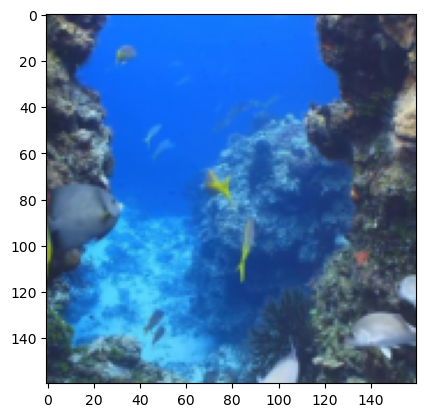

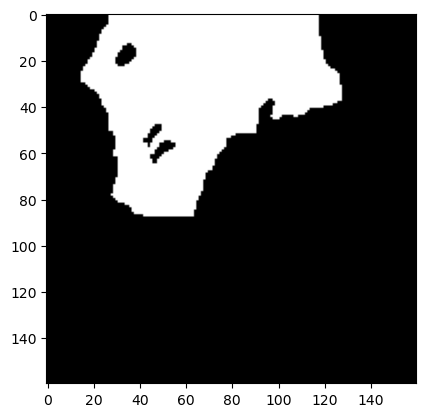

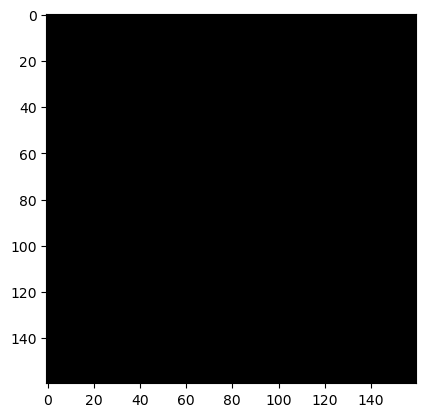

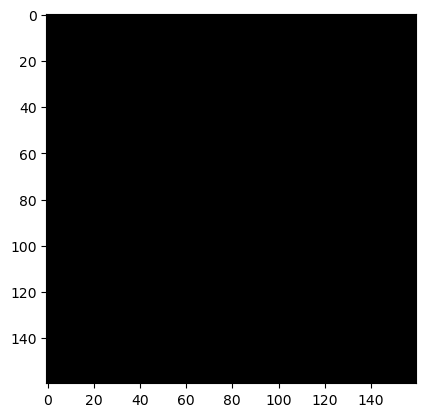

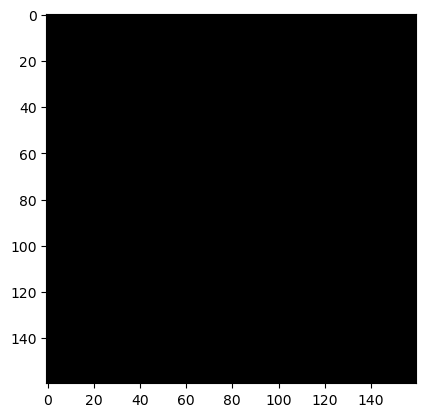

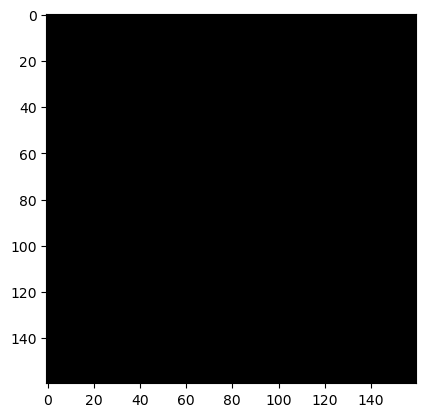

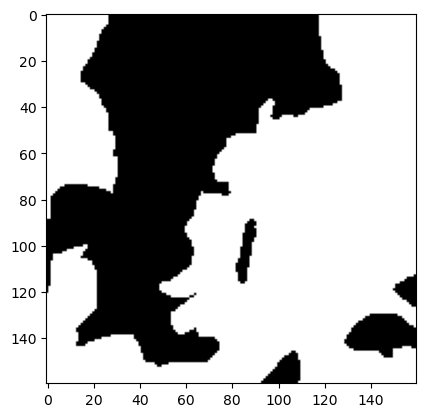

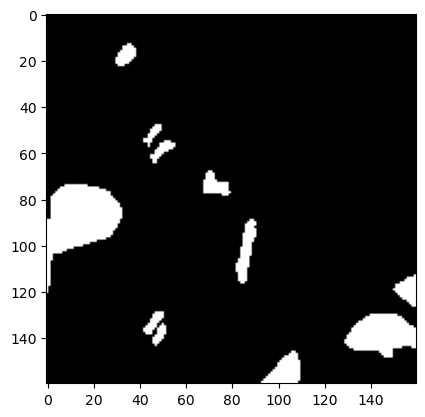

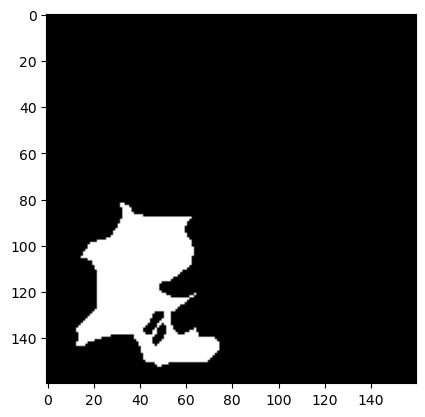

In [10]:
for images, labels in train_loader:
    break

num=0
grid = vutils.make_grid(images[num]*torch.tensor([0.2147, 0.2156, 0.2411]).view(1,3,1,1) + torch.tensor([0.2474, 0.4222, 0.4879]).view(1,3,1,1) )
plt.imshow(grid.numpy().transpose((1, 2, 0)))
plt.show()
for i in range(8):
    grid = vutils.make_grid((labels[num] == i).int()*255)
    plt.imshow(grid.numpy().transpose((1, 2, 0)))
    plt.show()

# UNet

## Model

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, no_of_class=3):
        super(UNet, self).__init__()
        
        # Downscaling part
        self.down_conv1 = self.conv_stage(input_channels, 64)
        self.down_conv2 = self.conv_stage(64, 128)
        self.down_conv3 = self.conv_stage(128, 256)
        self.down_conv4 = self.conv_stage(256, 512, dropout=True)

        # Bottleneck
        self.bottleneck_conv = self.conv_stage(512, 1024, dropout=True)

        # Upscaling part
        self.up6 = nn.Conv2d(1024, 512, kernel_size=2, padding='same')
        self.up7 = nn.Conv2d(512, 256, kernel_size=2, padding='same')
        self.up8 = nn.Conv2d(256, 128, kernel_size=2, padding='same')
        self.up9 = nn.Conv2d(128, 64, kernel_size=2, padding='same')
        self.up_conv4 = self.conv_stage(1024, 512)
        self.up_conv3 = self.conv_stage(512, 256)
        self.up_conv2 = self.conv_stage(256, 128)
        self.up_conv1 = self.conv_stage(128, 64)

        # Final conv (without any activation)
        self.final_conv = nn.Conv2d(64, no_of_class, kernel_size=1)

    def conv_stage(self, in_channels, out_channels, dropout=False):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                  nn.ReLU(inplace=True),
                  nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                  nn.ReLU(inplace=True)]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Downscaling
        conv1 = self.down_conv1(x)
        x = F.max_pool2d(conv1, kernel_size=2, stride=2)

        conv2 = self.down_conv2(x)
        x = F.max_pool2d(conv2, kernel_size=2, stride=2)

        conv3 = self.down_conv3(x)
        x = F.max_pool2d(conv3, kernel_size=2, stride=2)

        conv4 = self.down_conv4(x)
        x = F.max_pool2d(conv4, kernel_size=2, stride=2)

        # Bottleneck
        x = self.bottleneck_conv(x)

        # Upscaling + Concatenation
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.up6(x)
        x = torch.cat([x, conv4], dim=1)
        x = self.up_conv4(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.up7(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.up_conv3(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.up8(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.up_conv2(x)

        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        x = self.up9(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.up_conv1(x)

        # Final convolution
        x = self.final_conv(x)
        return x

In [16]:
unet_model = UNet(3, 8).to(device)

sample = torch.rand((1, 3, image_size, image_size)).to(device)
outputs = unet_model(sample)

outputs.shape

/home/sajad/anaconda3/envs/py311/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1008.)
  return F.conv2d(input, weight, bias, self.stride,


torch.Size([1, 8, 160, 160])

## Train

In [18]:
def train(model, trainloader, optimizer, criterion, device):
    # start = time.time()
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    miou = 0.0
    for i, data in enumerate(trainloader):
        # print('batch loading:', time.time() - start)
        if (i + 1) % 100 == 0:
            print('iter:', i+1, end='  ')
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(f"outputs: {outputs.dtype} , labels: {labels.dtype}", outputs.shape, labels.shape)
        loss = criterion(outputs, labels.reshape(-1,image_size,image_size))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        miou += compute_miou(outputs, labels)
        # print('step:', time.time() - start)
    miou = miou / len(trainloader)
    running_loss = running_loss / len(trainloader)
    return running_loss, miou

In [19]:
def validate(model, val_loader, criterion, device):
    model.eval()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    miou = 0.0
    with torch.inference_mode():
        for i, data in enumerate(val_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            # class_weights = torch.empty((len(data[1]), 1), dtype=torch.float32)
            # for i, j in enumerate(labels):
            #     class_weights[i][0] = dict_weights[int(j.item())]
            outputs = model(inputs)
            loss = criterion(outputs, labels.reshape(-1,image_size,image_size))
            running_loss += loss.item()
            miou += compute_miou(outputs, labels)
    miou = miou / len(val_loader)
    running_loss = running_loss / len(val_loader)
    return running_loss, miou

In [20]:
lr = 1e-4
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = UNet(3, 8).to(device)
optimizer = optim.Adam(model.parameters(),
                              lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=70, gamma=0.1)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_miou = np.zeros((0))
val_loss = np.zeros((0))
val_miou = np.zeros((0))
epoch_counter = 0
epoch_total = 0
min_val_loss = 99999999 #initialized as inf
max_miou = 0

In [28]:
# torch.cuda.empty_cache()
# gc.collect()

In [29]:
# vars_dict = load_vars('./tmp/unet_cp11.pkl')
# model.load_state_dict(vars_dict['state_dict'])
# train_loss = vars_dict['train_loss']
# train_miou = vars_dict['train_miou']
# val_loss = vars_dict['val_loss']
# val_miou = vars_dict['val_miou']
# min_val_loss = vars_dict['min_val_loss']
# epoch_counter = vars_dict['epoch_counter']

In [30]:
num_epochs = 150
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   time.time() - start_time
                  ))
    
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/unet_min_loss_cp12.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/unet_max_miou_cp12.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        'min_val_loss' : min_val_loss,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/unet_cp12.pkl', **tmp)

iter: 100  iter: 200  iter: 300  iter: 400  iter: 500  iter: 600  
Epoch [1/150], Training loss: 1.5051, Valid loss: 1.3670, Training miou: 0.2353, Val miou: 0.2784, time: 40.16 s
state dict saved. state dict saved. variables saved.
iter: 100  iter: 200  iter: 300  iter: 400  iter: 500  iter: 600  
Epoch [2/150], Training loss: 1.3555, Valid loss: 1.3239, Training miou: 0.2754, Val miou: 0.3006, time: 39.78 s
state dict saved. state dict saved. variables saved.
iter: 100  iter: 200  iter: 300  iter: 400  iter: 500  iter: 600  
Epoch [3/150], Training loss: 1.2935, Valid loss: 1.3461, Training miou: 0.3049, Val miou: 0.2957, time: 40.18 s
variables saved.
iter: 100  iter: 200  iter: 300  iter: 400  iter: 500  iter: 600  
Epoch [4/150], Training loss: 1.2503, Valid loss: 1.2570, Training miou: 0.3210, Val miou: 0.3201, time: 40.61 s
state dict saved. state dict saved. variables saved.
iter: 100  iter: 200  iter: 300  iter: 400  iter: 500  iter: 600  
Epoch [5/150], Training loss: 1.2110,

In [31]:
# vars_dict = load_vars('./tmp/unet_cp9.pkl')
# model.load_state_dict(vars_dict['state_dict'])
# train_loss = vars_dict['train_loss']
# train_miou = vars_dict['train_miou']
# val_loss = vars_dict['val_loss']
# val_miou = vars_dict['val_miou']
# min_val_loss = vars_dict['min_val_loss']
# epoch_counter = vars_dict['epoch_counter']

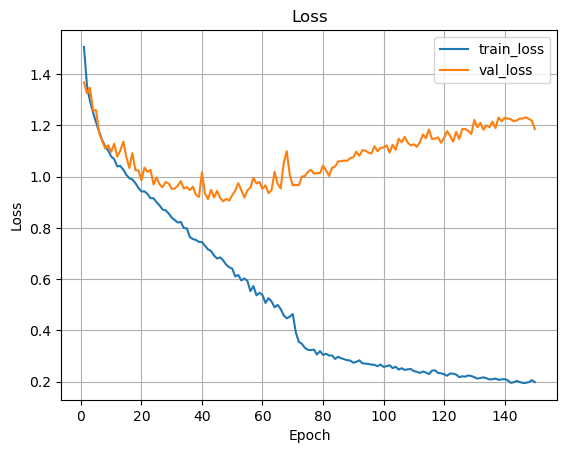

In [32]:
plot_results([train_loss[:], val_loss[:]], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

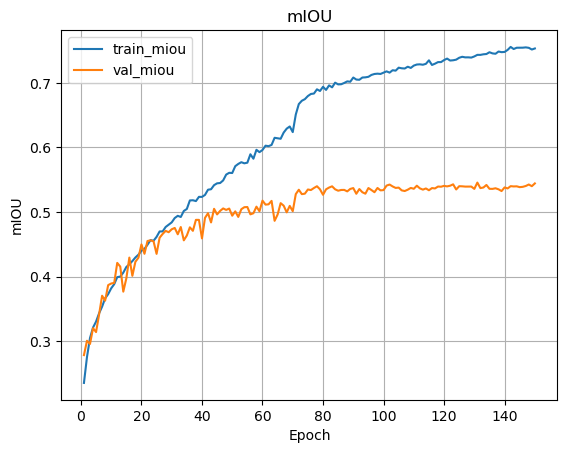

In [33]:
plot_results([train_miou[:], val_miou[:]], ['train_miou', 'val_miou'], 'mIOU', 'Epoch', 'mIOU')

## Evaluation

In [34]:
# best validation loss and epoch number of that
best_val_loss = min(val_loss)
best_epoch = val_loss.argmin()
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch+1}')

Best validation loss is: 0.9031003489122762
Epoch number of best validation loss is: 47


In [35]:
# best mIOU and epoch number of that
best_miou = max(val_miou)
best_epoch = val_miou.argmax()
print(f'Best mIOU is: {best_miou}')
print(f'Epoch number of best mIOU is: {best_epoch+1}')

Best mIOU is: 0.5456281304359436
Epoch number of best mIOU is: 131


In [21]:
checkpoint = torch.load('./models/unet_max_miou_cp12.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [22]:
def replace_with_tuples(input_tensor, tuple_list):
    # Create an empty tensor to store the RGB values
    output_tensor = torch.zeros((3, *input_tensor.shape), dtype=int)

    # Iterate through each pixel value and replace it with the corresponding tuple
    for j in range(input_tensor.shape[0]):
        for k in range(input_tensor.shape[1]):
            index = input_tensor[j, k]
            output_tensor[:, j, k] = torch.tensor(tuple_list[index])

    return output_tensor

In [23]:
def plotter(labels, outputs, input_images):
    all_true_masks = torch.zeros((3, image_size, image_size*labels.shape[0]))
    all_gen_masks = torch.zeros((3, image_size, image_size*labels.shape[0]))
    all_input_images = torch.zeros((3, image_size, image_size*labels.shape[0]))
    for i in range(labels.shape[0]):
        mask = replace_with_tuples(labels[i].reshape(image_size, image_size).cpu(), certain_rgb_values) / 255
        generated_mask = torch.argmax(outputs[i], dim=0).detach().cpu()
        generated_mask = replace_with_tuples(generated_mask, certain_rgb_values) / 255
        all_true_masks[:, :, i*image_size:(i+1)*image_size] = mask
        all_gen_masks[:, :, i*image_size:(i+1)*image_size] = generated_mask
        all_input_images[:, :, i*image_size:(i+1)*image_size] = input_images[i].cpu()
    # Create subplots
    fig, axs = plt.subplots(3, 1, figsize=(12, 4))  # Adjust the figure size as needed
    
    grid = vutils.make_grid(all_input_images*torch.tensor([0.2147, 0.2156, 0.2411]).view(1,3,1,1) + torch.tensor([0.2474, 0.4222, 0.4879]).view(1,3,1,1))
    axs[0].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[0].axis('off')
    
    grid = vutils.make_grid(all_gen_masks)
    axs[1].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[1].axis('off')
    
    grid = vutils.make_grid(all_true_masks)
    axs[2].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[2].axis('off')
    
    # Adjust layout to remove gaps
    plt.tight_layout()
    plt.show()

Test dataset mIOU = tensor(0.5665)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


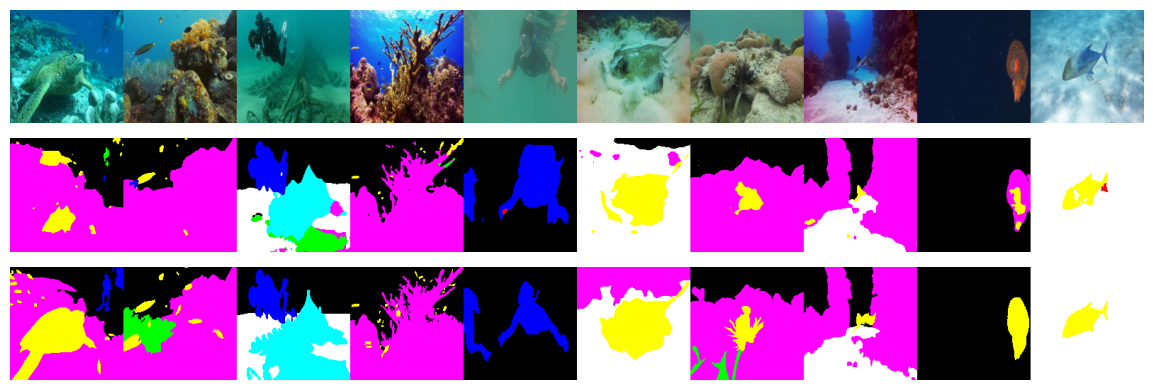

In [24]:
# print Test dataset mIOU and show random images from test dataset and predicted masks
batch_size = 10
num_workers = 8

test_dataset = CustomDataset("data/suim/test/", certain_rgb_values, split=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)

sum_miou = 0.0
data_num = 0
model.eval()
with torch.inference_mode():
    for data in test_loader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        data_num += inputs.shape[0]
        sum_miou += compute_miou(outputs, labels) * inputs.shape[0]
miou = sum_miou / data_num
print('Test dataset mIOU =', miou)

torch.manual_seed(2)
for data in test_loader:
    inputs, labels = data[0].to(device), data[1].to(device)
    outputs = model(inputs)
    break

plotter(labels[:10], outputs[:10], inputs[:10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


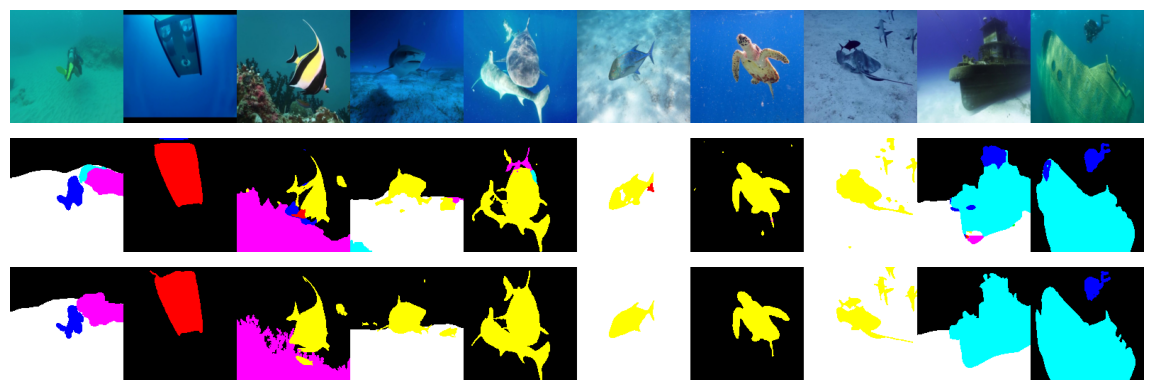

In [25]:
# show top 10 test dataset images and predicted masks
batch_size = 1
num_workers = 8

test_dataset = CustomDataset("data/suim/test/", certain_rgb_values, split=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

sum_miou = 0.0
data_num = 0
model.eval()
mious = torch.zeros(len(test_loader.dataset))
with torch.inference_mode():
    for i, data in enumerate(test_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        mious[i] = compute_miou(outputs, labels) * inputs.shape[0]
        
sorted_tensor, indices = torch.sort(mious, descending=True)

labels_store = torch.zeros((10, 1, 160, 160), dtype=int)
inputs_store = torch.zeros((10, 3, 160, 160))
outputs_store = torch.zeros((10, 8, 160, 160))
filled = 0
model.eval()
with torch.inference_mode():
    for i, data in enumerate(test_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        if i in indices[:10]:
            labels_store[filled] = labels
            inputs_store[filled] = inputs
            outputs_store[filled] = outputs
            filled += 1

plotter(labels_store[:10], outputs_store[:10], inputs_store[:10])

# PSPNet

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch import nn, optim
import torchvision.utils as vutils 
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import copy
import torch
import gc
import time
import os
import pickle

torch.__version__

'2.1.0+cu121'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

0

## Ploting functions

In [3]:
# Plot input sequences in one plot
def plot_results(log_lst, logs_name ,title, xlabel, ylabel):

    if len(logs_name) != len(log_lst):
        raise ValueError('logs_name and log_lst should have same length')
    
    x = np.arange(1, len(log_lst[0])+1) # x values starting from 1
    
    for logs, logs_name in zip(log_lst, logs_name):
        # plt.plot(x,logs, label=logs_name, marker='o', markersize=3)
        plt.plot(x,logs, label=logs_name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()
    

## save and load variables

In [4]:
def save_vars(file_path, **kwargs):
  if os.path.exists(file_path):
    with open(file_path, 'wb+') as f:
        pickle.dump(kwargs, f)
  else:
    with open(file_path, 'xb+') as f:
        pickle.dump(kwargs, f)

def load_vars(file_path):
    with open(file_path, 'rb') as f:
        vars_dict = pickle.load(f)
    return vars_dict

In [5]:
def compute_iou(pred_mask, true_mask, num_classes):
    ious = torch.zeros(num_classes)
    has_iou = torch.zeros(num_classes, dtype=torch.bool)
    for class_idx in range(num_classes):
        pred_mask_class = (pred_mask == class_idx)
        true_mask_class = (true_mask == class_idx)
        has_iou[class_idx] = true_mask_class.any()
    
        intersection = torch.logical_and(true_mask_class, pred_mask_class).sum().float()
        union = torch.logical_or(true_mask_class, pred_mask_class).sum().float()

        class_iou = intersection / union if union != 0 else torch.tensor(0)
        ious[class_idx] = class_iou.item()
    return ious[has_iou]

def compute_miou(pred_masks, true_masks):
    batch_size = pred_masks.size(0)
    num_classes = pred_masks.size(1)
    miou_sum = 0.0

    for i in range(batch_size):
        pred_mask = torch.argmax(pred_masks[i], dim=0)
        true_mask = true_masks[i]

        ious = compute_iou(pred_mask, true_mask, num_classes)
        miou_sum += ious.mean()

    miou = miou_sum / batch_size
    return miou

## Data

In [7]:
def split_names(names):
    # Create a dictionary to store names based on the first part
    names_dict = {}
    for name in names:
        parts = name.split('_')
        first_part = '_'.join(parts[:-2])
        if first_part not in names_dict:
            names_dict[first_part] = []
        names_dict[first_part].append(name)

    # Create two lists for the result
    list_90_percent = []
    list_10_percent = []

    # Distribute names to the two lists
    for first_part, name_list in names_dict.items():
        # Determine the cutoff index for 90%
        cutoff_index = int(len(name_list) * 0.9)

        # Extend the 90% and 10% lists
        list_90_percent.extend(name_list[:cutoff_index])
        list_10_percent.extend(name_list[cutoff_index:])

    return list_90_percent, list_10_percent

In [8]:
batch_size = 16
num_workers = 8
image_size = 160

class CustomSegmentationTransform:
    def __init__(self, color_jitter_prob=0.5, crop_prob=0.3, crop_size=(480, 480), flip_prob=0.5, rotation_degrees=10, grayscale_prob=0.2, max_shift=(10, 10)):
        self.flip_prob = flip_prob
        self.color_jitter_prob = color_jitter_prob
        self.rotation_degrees = rotation_degrees
        self.max_shift = max_shift
        self.grayscale_prob = grayscale_prob
        self.crop_size = crop_size
        self.crop_prob = crop_prob

    def apply_grayscale(self, image):
        # Convert the image to grayscale
        return transforms.functional.to_grayscale(image, num_output_channels=3)

    def apply_random_crop(self, image, mask):
        # Randomly crop the image and mask
        try:
            i, j, h, w = transforms.RandomCrop.get_params(image, output_size=self.crop_size)
            croped_image = transforms.functional.crop(image, i, j, h, w)
            croped_mask = transforms.functional.crop(mask, i, j, h, w)
        except ValueError:
            return image, mask
        return croped_image, croped_mask
    
    def __call__(self, image, mask):

        # Apply grayscale variation
        if torch.rand(1).item() < self.grayscale_prob:
            image = self.apply_grayscale(image)

        # Random horizontal flip
        if torch.rand(1).item() < self.flip_prob:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)

        # Apply random crop
        if torch.rand(1).item() < self.crop_prob:
            image, mask = self.apply_random_crop(image, mask)
        
        return image, mask

class CustomDataset(Dataset):
    def __init__(self, data_dir, certain_rgb_values, split=True, train=True, augmentation=False, random_seed=42):
        self.certain_rgb_values = certain_rgb_values
        self.augmentation = augmentation
        self.images_dir = data_dir+'images/'
        self.masks_dir = data_dir+'masks/'
        self.image_names = os.listdir(self.images_dir)
        if split:
            list_90, list_10 = split_names(self.image_names)
            if train: # Create Train dataset
                self.image_names = list_90
            else: # Create Val dataset
                self.image_names = list_10
        # Convert to tensor, resize and normalize
        self.image_transform = transforms.Compose([
            transforms.ToTensor(), 
            transforms.Resize((image_size, image_size), antialias=True, interpolation=Image.BILINEAR),
            transforms.Normalize([0.2474, 0.4222, 0.4879], [0.2147, 0.2156, 0.2411])
                                             ])
        self.mask_transform = transforms.Compose([ 
            transforms.Resize((image_size, image_size), interpolation=Image.NEAREST)])
        
        self.custom_transform = CustomSegmentationTransform()
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_path = self.images_dir + self.image_names[idx]
        image = Image.open(image_path).convert("RGB")
        mask_path = self.masks_dir + self.image_names[idx][:-4] + '.bmp'
        mask = Image.open(mask_path).convert("RGB")

        # Apply the custom transformation
        mask = self.replace_rgb_values(mask)

        if self.augmentation:
            image, mask = self.custom_transform(image, mask)
            
        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        return image, mask

    def replace_rgb_values(self, image):
        # Convert PIL Image to NumPy array
        image_array = np.array(image)
        # print(image_array.shape)
        image_array = torch.tensor(image_array)
        output = torch.zeros((1, image_array.shape[0], image_array.shape[1]), dtype=int)

        # Replace certain RGB values with corresponding replacement values
        for i in range(len(self.certain_rgb_values)):
            mask = torch.all(image_array == torch.tensor(self.certain_rgb_values[i]), axis=-1)
            # print('mask', mask.shape)
            output[0, mask] = i
        return output

certain_rgb_values = [(0, 0, 0), (0, 0, 255), (0, 255, 0), (0, 255, 255), (255, 0, 0), (255, 0, 255), (255, 255, 0), (255, 255, 255)]  # Replace with actual RGB values

train_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=True, augmentation=True)
val_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=False, augmentation=False)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True, pin_memory=True)

# calculate class weights
custom_dataset = CustomDataset("data/suim/train_val/", certain_rgb_values, split=True, train=True, augmentation=False, random_seed=42)
custom_loader = DataLoader(custom_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)
num_data_in_each_class = torch.tensor([0 for _ in range(8)])
channel_sums = torch.zeros(3)
channel_squared_sums = torch.zeros(3)
for data in custom_loader:
    images, labels = data
    # Calculate sums and squared sums
    channel_sums += torch.sum(images, dim=(0, 2, 3))
    channel_squared_sums += torch.sum(images**2, dim=(0, 2, 3))
    # Calculate unique values and number of them
    uniques, counts = labels.unique(return_counts=True)
    for i, label in enumerate(uniques):
        num_data_in_each_class[label] += counts[i]

weights = torch.zeros(8, device=device, dtype=torch.float)
for i in range(8):
    weights[i] = (num_data_in_each_class.sum()/num_data_in_each_class[i])

# Calculate mean and variance
num_samples = len(train_loader.dataset)
channel_means = channel_sums / (num_samples * images.size(2) * images.size(3))
channel_variances = (channel_squared_sums / (num_samples * images.size(2) * images.size(3))) - channel_means**2
# Print the results
print("Channel Means:", channel_means)
print("Channel STD:", channel_variances.sqrt())

Channel Means: tensor([0.0019, 0.0024, 0.0020])
Channel STD: tensor([1.0001, 0.9980, 0.9974])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


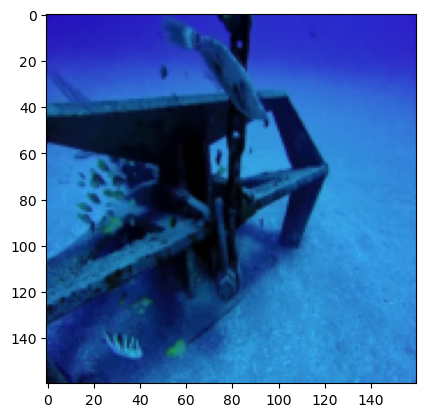

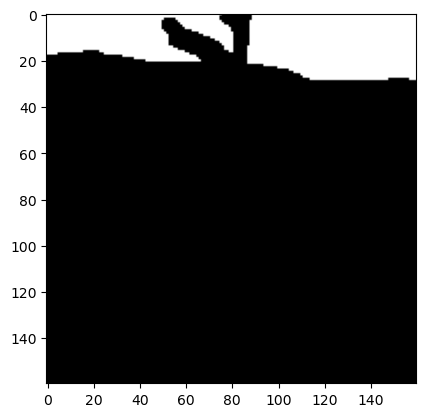

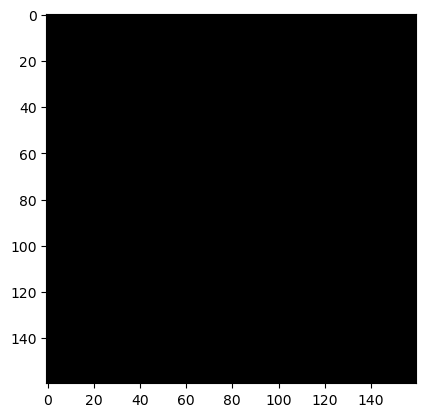

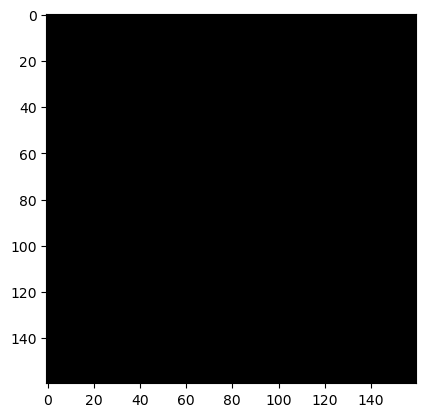

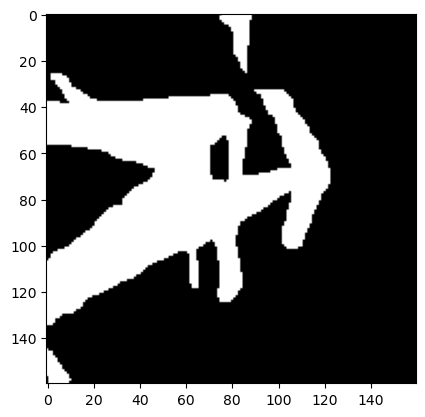

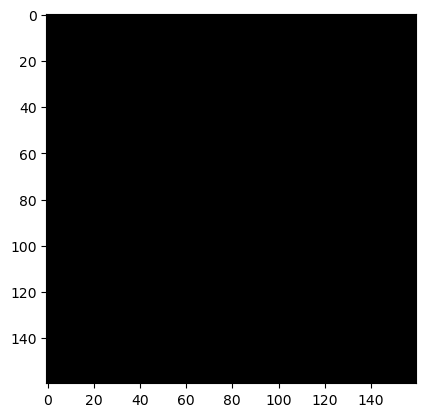

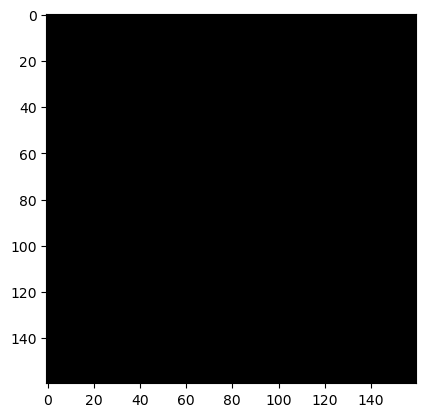

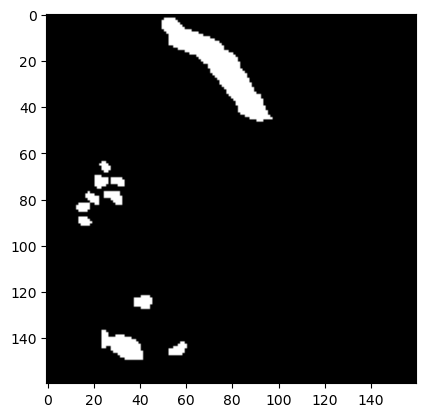

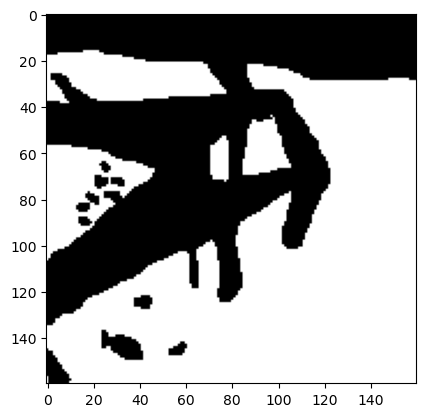

In [60]:
for images, labels in train_loader:
    break

num=0
grid = vutils.make_grid(images[num]*torch.tensor([0.2147, 0.2156, 0.2411]).view(1,3,1,1) + torch.tensor([0.2474, 0.4222, 0.4879]).view(1,3,1,1) )
plt.imshow(grid.numpy().transpose((1, 2, 0)))
plt.show()
for i in range(8):
    grid = vutils.make_grid((labels[num] == i).int()*255)
    plt.imshow(grid.numpy().transpose((1, 2, 0)))
    plt.show()

## Model

In [49]:
# Reference URL: https://github.com/mehtanihar/pspnet/blob/master/models/network.py
class PyramidPool(nn.Module):

	def __init__(self, in_features, out_features, pool_size):
		super(PyramidPool,self).__init__()

		self.features = nn.Sequential(
			nn.AdaptiveAvgPool2d(pool_size),
			nn.Conv2d(in_features, out_features, 1, bias=False),
			nn.BatchNorm2d(out_features, momentum=.95),
			nn.ReLU(inplace=True)
		)


	def forward(self, x):
         size=x.size()
         output = F.interpolate(self.features(x), size[2:], mode='bilinear', align_corners=False)
         return output


class PSPNet(nn.Module):

    def __init__(self, num_classes, pretrained = False):
        super(PSPNet,self).__init__()
        self.backbone = torchvision.models.mobilenet_v2(pretrained=True)

        mid_features_num = 1280
        self.layer5a = PyramidPool(mid_features_num, 512, 1)
        self.layer5b = PyramidPool(mid_features_num, 512, 2)
        self.layer5c = PyramidPool(mid_features_num, 512, 3)
        self.layer5d = PyramidPool(mid_features_num, 512, 6)




        self.final = nn.Sequential(
        	nn.Conv2d(3328, 512, 3, padding=1, bias=False),
        	nn.BatchNorm2d(512, momentum=.95),
        	nn.ReLU(inplace=True),
        	nn.Dropout(.1),
        	nn.Conv2d(512, num_classes, 1),
        )



    def forward(self, x):

        size=x.size()
        x = self.backbone.features(x)
        # print(x.shape)
        x = self.final(torch.cat([
        	x,
        	self.layer5a(x),
        	self.layer5b(x),
        	self.layer5c(x),
        	self.layer5d(x),
        ], 1))

        return F.interpolate(x, size[2:], mode='bilinear', align_corners=False)

In [50]:
pspnet_model = PSPNet(8).to(device)

sample = torch.rand((10, 3, 160, 160)).to(device)
outputs = pspnet_model(sample)

outputs.shape

torch.Size([10, 8, 160, 160])

## Train

In [19]:
def train(model, trainloader, optimizer, criterion, device):
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    miou = 0.0
    for i, data in enumerate(trainloader):
        if (i + 1) % 20 == 0:
            print('iter:', i+1, end='  ')
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.reshape(-1,image_size,image_size))
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        miou += compute_miou(outputs, labels)
    miou = miou / len(trainloader)
    running_loss = running_loss / len(trainloader)
    return running_loss, miou

In [20]:
def validate(model, val_loader, criterion, device):
    model.eval()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    miou = 0.0
    with torch.inference_mode():
        for i, data in enumerate(val_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels.reshape(-1,image_size,image_size))
            running_loss += loss.item()
            miou += compute_miou(outputs, labels)
    miou = miou / len(val_loader)
    running_loss = running_loss / len(val_loader)
    return running_loss, miou

In [21]:
lr = 1e-4
device = 'cuda'
# Initialize the model and the optimizer
torch.manual_seed(40)
model = PSPNet(8).to(device)
optimizer = optim.Adam(model.parameters(),
                              lr=lr)
criterion = nn.CrossEntropyLoss()

train_loss = np.zeros((0))
train_miou = np.zeros((0))
val_loss = np.zeros((0))
val_miou = np.zeros((0))
epoch_counter = 0
epoch_total = 0
min_val_loss = 99999999 #initialized as inf
max_miou = 0

In [24]:
num_epochs = 50
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   # scheduler.get_last_lr()[0],
                   # lr,
                   time.time() - start_time
                  ))
    
    # if (loss_prev*0.98 < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.RMSprop(model.parameters(),
    #                           lr=lr, foreach=True)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_min_loss_cp1.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_max_miou_cp1.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    # scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        # 'lr' : scheduler.get_last_lr()[0],
        # 'lr' : lr,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/pspnet_cp1.pkl', **tmp)
    # torch.cuda.empty_cache()
    # gc.collect()

iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [1/50], Training loss: 1.1160, Valid loss: 1.0104, Training miou: 0.3521, Val miou: 0.3780, time: 21.08 s
state dict saved. state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [2/50], Training loss: 0.8266, Valid loss: 0.9172, Training miou: 0.4015, Val miou: 0.3882, time: 21.65 s
state dict saved. state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [3/50], Training loss: 0.7478, Valid loss: 0.9076, Training miou: 0.4255, Val miou: 0.3842, time: 22.28 s
state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [4/50], Training loss: 0.7019, Valid loss: 0.8418, Training miou: 0.4389, Val miou: 0.4171, time: 21.93 s
state dict saved. state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [5/50], Training loss: 0.6395, Valid loss: 0.9402, Training miou: 0.4541, Val miou: 0.3959, time: 21.61 s
variables saved.
iter: 20  iter: 40  iter

In [32]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [33]:
num_epochs = 30
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   # scheduler.get_last_lr()[0],
                   # lr,
                   time.time() - start_time
                  ))
    
    # if (loss_prev*0.98 < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.RMSprop(model.parameters(),
    #                           lr=lr, foreach=True)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_min_loss_cp1.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_max_miou_cp1.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    # scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        # 'lr' : scheduler.get_last_lr()[0],
        # 'lr' : lr,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/pspnet_cp1.pkl', **tmp)
    # torch.cuda.empty_cache()
    # gc.collect()

iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [51/80], Training loss: 0.2944, Valid loss: 1.0099, Training miou: 0.6256, Val miou: 0.5082, time: 20.26 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [52/80], Training loss: 0.2852, Valid loss: 0.9397, Training miou: 0.6282, Val miou: 0.5208, time: 20.65 s
state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [53/80], Training loss: 0.2806, Valid loss: 0.9785, Training miou: 0.6341, Val miou: 0.5057, time: 20.67 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [54/80], Training loss: 0.2807, Valid loss: 0.9405, Training miou: 0.6323, Val miou: 0.5162, time: 22.40 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [55/80], Training loss: 0.2743, Valid loss: 0.9944, Training miou: 0.6354, Val miou: 0.5212, time: 22.05 s
state dict saved. variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [56/80], Training loss: 0.2756, Valid loss: 0.9773, Training m

In [34]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)

In [35]:
num_epochs = 20
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   # scheduler.get_last_lr()[0],
                   # lr,
                   time.time() - start_time
                  ))
    
    # if (loss_prev*0.98 < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.RMSprop(model.parameters(),
    #                           lr=lr, foreach=True)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_min_loss_cp1.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_max_miou_cp1.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    # scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        # 'lr' : scheduler.get_last_lr()[0],
        # 'lr' : lr,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/pspnet_cp1.pkl', **tmp)
    # torch.cuda.empty_cache()
    # gc.collect()

iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [81/100], Training loss: 0.2519, Valid loss: 1.0568, Training miou: 0.6503, Val miou: 0.5107, time: 21.71 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [82/100], Training loss: 0.2510, Valid loss: 0.9913, Training miou: 0.6484, Val miou: 0.5178, time: 21.97 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [83/100], Training loss: 0.2504, Valid loss: 1.0192, Training miou: 0.6518, Val miou: 0.5088, time: 22.24 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [84/100], Training loss: 0.2511, Valid loss: 0.9995, Training miou: 0.6503, Val miou: 0.5154, time: 22.07 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [85/100], Training loss: 0.2494, Valid loss: 1.0385, Training miou: 0.6513, Val miou: 0.5231, time: 22.03 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [86/100], Training loss: 0.2497, Valid loss: 1.0172, Training miou: 0.6509, Val miou: 0.5178,

In [61]:
num_epochs = 20
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   # scheduler.get_last_lr()[0],
                   # lr,
                   time.time() - start_time
                  ))
    
    # if (loss_prev*0.98 < train_loss[epoch_counter]):
    #     lr = lr * 0.5
    #     optimizer = optim.RMSprop(model.parameters(),
    #                           lr=lr, foreach=True)        
    # loss_prev = train_loss[epoch_counter]
    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_min_loss_cp1.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_max_miou_cp1.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    # scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        # 'lr' : scheduler.get_last_lr()[0],
        # 'lr' : lr,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/pspnet_cp1.pkl', **tmp)
    # torch.cuda.empty_cache()
    # gc.collect()

iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [101/120], Training loss: 0.2483, Valid loss: 1.0568, Training miou: 0.6534, Val miou: 0.5134, time: 20.26 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [102/120], Training loss: 0.2482, Valid loss: 0.9935, Training miou: 0.6505, Val miou: 0.5193, time: 20.61 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [103/120], Training loss: 0.2478, Valid loss: 1.0212, Training miou: 0.6538, Val miou: 0.5098, time: 21.03 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [104/120], Training loss: 0.2486, Valid loss: 1.0026, Training miou: 0.6517, Val miou: 0.5163, time: 21.27 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [105/120], Training loss: 0.2469, Valid loss: 1.0408, Training miou: 0.6531, Val miou: 0.5240, time: 21.25 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [106/120], Training loss: 0.2474, Valid loss: 1.0208, Training miou: 0.6523, Val miou: 0

In [62]:
optimizer = optim.Adam(model.parameters(), lr=1e-7)

In [63]:
num_epochs = 30
torch.manual_seed(40)
epoch_total = epoch_counter + num_epochs
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_miou = np.concatenate((train_miou, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_miou = np.concatenate((val_miou, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    start_time = time.time()
    # train for one epoch
    tmp_metrics = train(model, train_loader, optimizer, criterion, device)
    train_loss[epoch_counter], train_miou[epoch_counter] = tmp_metrics
    # print('Epoch Training Done.', end=' ')
    # calculate validation loss for this epoch
    tmp_metrics = validate(model, val_loader, criterion, device)
    val_loss[epoch_counter], val_miou[epoch_counter] = tmp_metrics
    # print the results for this epoch
    if (epoch_counter+1) % 1 == 0:
        print('\nEpoch [{}/{}], Training loss: {:.4f}, Valid loss: {:.4f}, Training miou: {:.4f}, Val miou: {:.4f}, time: {:.2f} s'
           .format(epoch_counter+1, epoch_total, train_loss[epoch_counter],
                   val_loss[epoch_counter], train_miou[epoch_counter], 
                   val_miou[epoch_counter],
                   # scheduler.get_last_lr()[0],
                   # lr,
                   time.time() - start_time
                  ))

    if min_val_loss > val_loss[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_min_loss_cp1.pt')
        print('state dict saved.', end=' ')
        min_val_loss = val_loss[epoch_counter]
    if max_miou < val_miou[epoch_counter]:
        torch.save(model.state_dict(), './models/pspnet_max_miou_cp1.pt')
        print('state dict saved.', end=' ')
        max_miou = val_miou[epoch_counter]
    # scheduler.step()
    epoch_counter += 1
    tmp = {'train_loss' : train_loss[:epoch_counter],
        'train_miou' : train_miou[:epoch_counter],
        'val_loss' : val_loss[:epoch_counter],
        'val_miou' : val_miou[:epoch_counter],
        # 'loss_prev' : loss_prev,
        'min_val_loss' : min_val_loss,
        # 'lr' : scheduler.get_last_lr()[0],
        # 'lr' : lr,
        'epoch_counter' : epoch_counter,
        'state_dict' : model.cpu().state_dict(),}
    print('variables saved.')
    model = model.to(device)
    save_vars('./tmp/pspnet_cp1.pkl', **tmp)
    # torch.cuda.empty_cache()
    # gc.collect()

iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [121/150], Training loss: 0.2461, Valid loss: 1.0631, Training miou: 0.6549, Val miou: 0.5138, time: 22.15 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [122/150], Training loss: 0.2463, Valid loss: 0.9994, Training miou: 0.6515, Val miou: 0.5192, time: 21.92 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [123/150], Training loss: 0.2458, Valid loss: 1.0262, Training miou: 0.6544, Val miou: 0.5093, time: 22.25 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [124/150], Training loss: 0.2468, Valid loss: 1.0056, Training miou: 0.6523, Val miou: 0.5161, time: 22.52 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [125/150], Training loss: 0.2452, Valid loss: 1.0432, Training miou: 0.6536, Val miou: 0.5240, time: 22.61 s
variables saved.
iter: 20  iter: 40  iter: 60  iter: 80  
Epoch [126/150], Training loss: 0.2457, Valid loss: 1.0223, Training miou: 0.6532, Val miou: 0

In [31]:
# vars_dict = load_vars('./tmp/unet_cp9.pkl')
# model.load_state_dict(vars_dict['state_dict'])
# train_loss = vars_dict['train_loss']
# train_miou = vars_dict['train_miou']
# val_loss = vars_dict['val_loss']
# val_miou = vars_dict['val_miou']
# min_val_loss = vars_dict['min_val_loss']
# epoch_counter = vars_dict['epoch_counter']

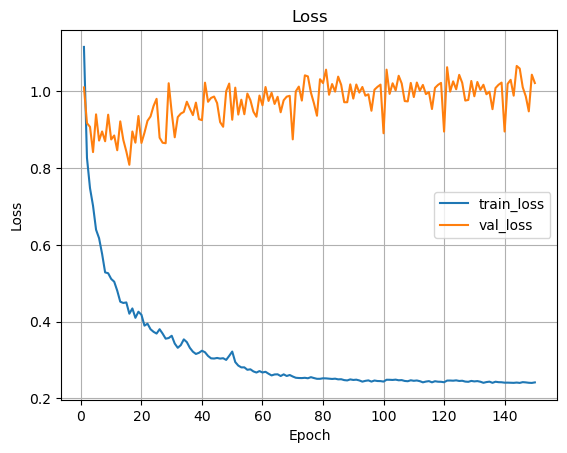

In [64]:
plot_results([train_loss[:], val_loss[:]], ['train_loss', 'val_loss'], 'Loss', 'Epoch', 'Loss')

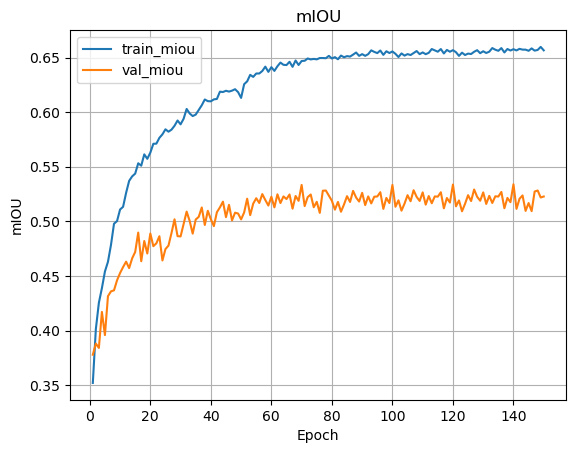

In [65]:
plot_results([train_miou[:], val_miou[:]], ['train_miou', 'val_miou'], 'mIOU', 'Epoch', 'mIOU')

## Evaluation

In [66]:
# best validation loss and epoch number of that
best_val_loss = min(val_loss)
best_epoch = val_loss.argmin()
print(f'Best validation loss is: {best_val_loss}')
print(f'Epoch number of best validation loss is: {best_epoch+1}')

Best validation loss is: 0.8087770475281609
Epoch number of best validation loss is: 16


In [67]:
# best mIOU and epoch number of that
best_miou = max(val_miou)
best_epoch = val_miou.argmax()
print(f'Best mIOU is: {best_miou}')
print(f'Epoch number of best mIOU is: {best_epoch+1}')

Best mIOU is: 0.5339611172676086
Epoch number of best mIOU is: 140


In [68]:
checkpoint = torch.load('./models/pspnet_max_miou_cp1.pt')
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [69]:
def replace_with_tuples(input_tensor, tuple_list):
    # Create an empty tensor to store the RGB values
    output_tensor = torch.zeros((3, *input_tensor.shape), dtype=int)

    # Iterate through each pixel value and replace it with the corresponding tuple
    for j in range(input_tensor.shape[0]):
        for k in range(input_tensor.shape[1]):
            index = input_tensor[j, k]
            output_tensor[:, j, k] = torch.tensor(tuple_list[index])

    return output_tensor

In [70]:
def plotter(labels, outputs, input_images):
    all_true_masks = torch.zeros((3, image_size, image_size*labels.shape[0]))
    all_gen_masks = torch.zeros((3, image_size, image_size*labels.shape[0]))
    all_input_images = torch.zeros((3, image_size, image_size*labels.shape[0]))
    for i in range(labels.shape[0]):
        mask = replace_with_tuples(labels[i].reshape(image_size, image_size).cpu(), certain_rgb_values) / 255
        generated_mask = torch.argmax(outputs[i], dim=0).detach().cpu()
        generated_mask = replace_with_tuples(generated_mask, certain_rgb_values) / 255
        all_true_masks[:, :, i*image_size:(i+1)*image_size] = mask
        all_gen_masks[:, :, i*image_size:(i+1)*image_size] = generated_mask
        all_input_images[:, :, i*image_size:(i+1)*image_size] = input_images[i].cpu()
    # Create subplots
    fig, axs = plt.subplots(3, 1, figsize=(12, 4))  # Adjust the figure size as needed
    
    # Plot data on each subplot
    grid = vutils.make_grid(all_input_images*torch.tensor([0.2147, 0.2156, 0.2411]).view(1,3,1,1) + torch.tensor([0.2474, 0.4222, 0.4879]).view(1,3,1,1))
    axs[0].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[0].axis('off')
    
    grid = vutils.make_grid(all_gen_masks)
    axs[1].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[1].axis('off')
    
    grid = vutils.make_grid(all_true_masks)
    axs[2].imshow(grid.numpy().transpose((1, 2, 0)))
    axs[2].axis('off')
    
    # Adjust layout to remove gaps
    plt.tight_layout()
    plt.show()

Test dataset mIOU = tensor(0.5298)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


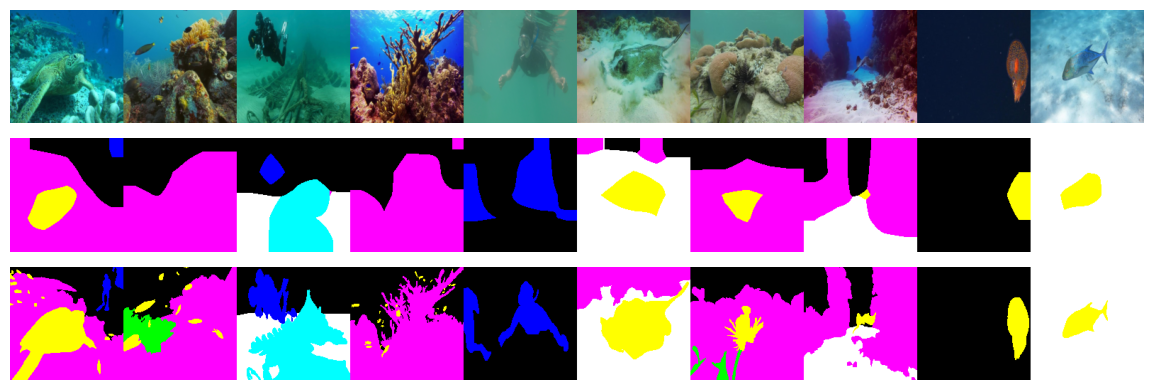

In [72]:
# print Test dataset mIOU and show random images from test dataset and predicted masks
batch_size = 10
num_workers = 8

test_dataset = CustomDataset("data/suim/test/", certain_rgb_values, split=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)

sum_miou = 0.0
data_num = 0
model.eval()
with torch.inference_mode():
    for data in test_loader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        data_num += inputs.shape[0]
        sum_miou += compute_miou(outputs, labels) * inputs.shape[0]
miou = sum_miou / data_num
print('Test dataset mIOU =', miou)

torch.manual_seed(2)
for data in test_loader:
    inputs, labels = data[0].to(device), data[1].to(device)
    outputs = model(inputs)
    break

plotter(labels[:10], outputs[:10], inputs[:10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


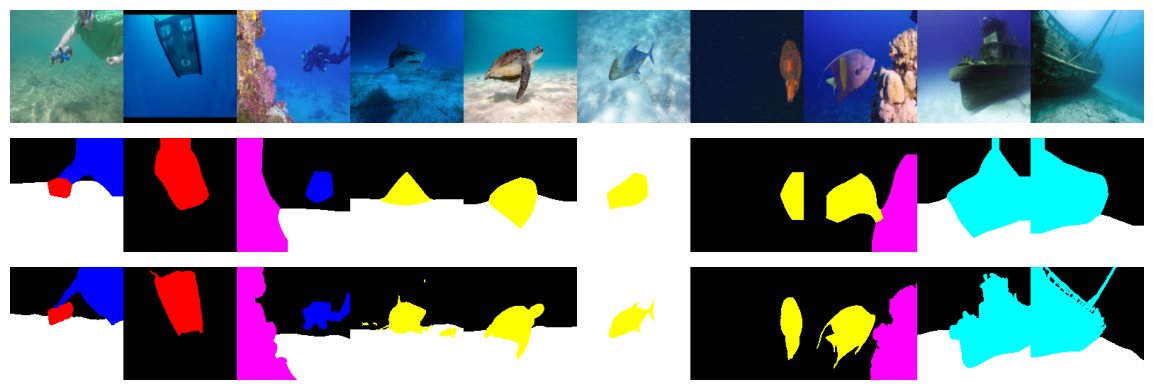

In [74]:
# show top 10 test dataset images and predicted masks
batch_size = 1
num_workers = 8

test_dataset = CustomDataset("data/suim/test/", certain_rgb_values, split=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

sum_miou = 0.0
data_num = 0
model.eval()
mious = torch.zeros(len(test_loader.dataset))
with torch.inference_mode():
    for i, data in enumerate(test_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        mious[i] = compute_miou(outputs, labels) * inputs.shape[0]
        
sorted_tensor, indices = torch.sort(mious, descending=True)

labels_store = torch.zeros((10, 1, 160, 160), dtype=int)
inputs_store = torch.zeros((10, 3, 160, 160))
outputs_store = torch.zeros((10, 8, 160, 160))
filled = 0
model.eval()
with torch.inference_mode():
    for i, data in enumerate(test_loader):
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        if i in indices[:10]:
            labels_store[filled] = labels
            inputs_store[filled] = inputs
            outputs_store[filled] = outputs
            filled += 1

plotter(labels_store[:10], outputs_store[:10], inputs_store[:10])